# Gradient Descent & Optimization

In the previous lesson, we learned how to frame a business problem and translate it into a Target Vector ($y$) and a Feature Matrix ($X$). We established that our goal is to find a mathematical function that maps $X$ to $y$ while minimizing the error. 

But *how* does a machine actually minimize that error? It cannot simply guess trillions of possible parameter combinations until it finds the best one. 

Enter **Gradient Descent**. This algorithm is the absolute beating heart of modern Artificial Intelligence. It is the optimization engine that powers everything from simple Linear Regression models to massive Large Language Models (like the one you are interacting with right now).

If a Machine Learning model is a vehicle, the Cost Function is the steering wheel, and Gradient Descent is the engine pushing it forward. In this lesson, we will unpack the calculus that allows an algorithm to "learn" from its mistakes and mathematically guarantee an optimal solution.

Let us set up our Python environment to visualize this optimization process.

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set professional visualization styling
sns.set_theme(style="whitegrid")

print("✅ Optimization & Calculus Environment Ready.")

✅ Optimization & Calculus Environment Ready.


# 1. The Cost Function Landscape

Before we can optimize, we must define what we are optimizing. Recall the **Cost Function** $J(\theta)$, which calculates the Mean Squared Error of our predictions. 

Imagine you are trying to find a single parameter, $\theta_1$ (the slope of a line). If you calculate the Cost $J(\theta_1)$ for every possible value of $\theta_1$, and plot those values on a graph, you get a convex, U-shaped parabola. 

The goal of Machine Learning is to find the exact value of $\theta_1$ that sits at the absolute bottom of that valley. This point represents the **Global Minimum**—the state where the model has the lowest possible error.

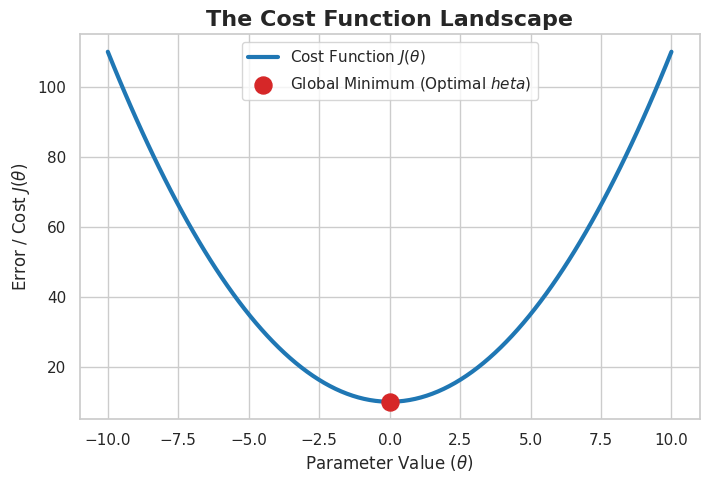

In [17]:
# 1. Define a mathematical Cost Function: J(theta) = theta^2 + 10
def cost_function(theta):
    return theta**2 + 10

# 2. Define the Derivative of the Cost Function (The Gradient): J'(theta) = 2*theta
def gradient(theta):
    return 2 * theta

# Generate the U-shaped landscape
theta_values = np.linspace(-10, 10, 100)
cost_values = cost_function(theta_values)

plt.figure(figsize=(8, 5))
plt.plot(theta_values, cost_values, color='#1f77b4', linewidth=3, label=r'Cost Function $J(\theta)$')
plt.scatter(0, 10, color='#d62728', s=150, zorder=5, label='Global Minimum (Optimal $\theta$)')
plt.title("The Cost Function Landscape", fontsize=16, fontweight='bold')
plt.xlabel(r"Parameter Value ($\theta$)")
plt.ylabel(r"Error / Cost $J(\theta)$")
plt.legend()
plt.show()

# 2. The Calculus of Learning (The Gradient)

If the algorithm starts at a random guess (e.g., $\theta = -8$), how does it know which direction to move to find the bottom? It uses **Calculus**.

By taking the partial derivative of the Cost Function with respect to our parameters, we calculate the **Gradient**. 
*   The Gradient is simply the *slope* of the curve at our current position.
*   If the slope is negative (pointing downward to the right), the algorithm knows it must increase $\theta$ to move toward the minimum.
*   If the slope is positive (pointing upward to the right), the algorithm must decrease $\theta$.

Mathematically, the Gradient Descent update rule is written as:
$$\theta_j := \theta_j - \alpha \frac{\partial}{\partial \theta_j} J(\theta)$$

Where:
*   $:=$ means "overwrite the current value with the new value".
*   $\theta_j$ is the specific parameter we are updating.
*   $\frac{\partial}{\partial \theta_j} J(\theta)$ is the Gradient (the slope).
*   $\alpha$ is the **Learning Rate**.

# 3. The Learning Rate ($\alpha$)

Notice the subtraction sign in the equation above. We are subtracting the slope to ensure we always move *against* the gradient (downhill). But how big of a step should we take? That is controlled by $\alpha$, the **Learning Rate**.

*   **If $\alpha$ is too small**: The algorithm takes microscopic steps. It will eventually reach the bottom, but it might take 3 weeks of server compute time to do so.
*   **If $\alpha$ is too large**: The algorithm takes a massive step, overshoots the minimum, lands on the opposite side of the valley higher than it started, and mathematically explodes to infinity (divergence).

Let's write a Python script to simulate Gradient Descent and plot its physical steps down the curve.

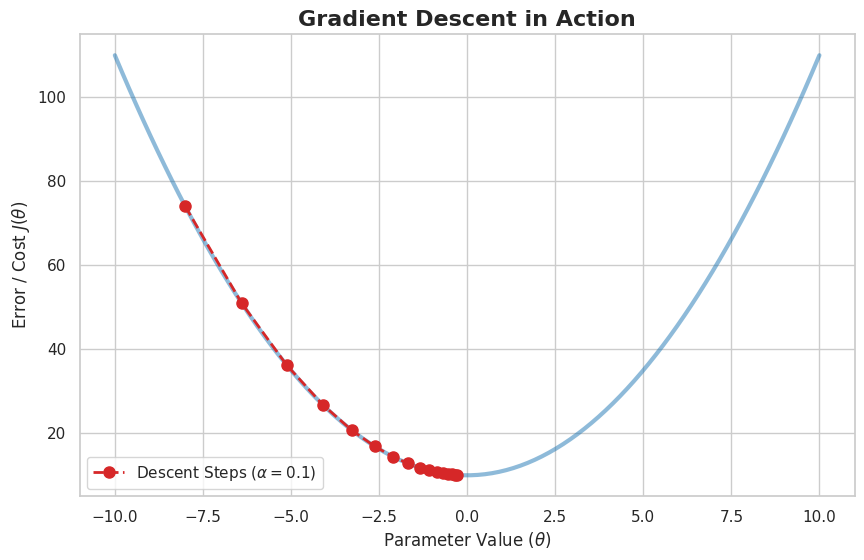

In [18]:
# Gradient Descent Algorithm implementation
def simulate_gradient_descent(starting_theta, learning_rate, iterations):
    theta = starting_theta
    history_theta = [theta]
    history_cost = [cost_function(theta)]
    
    for _ in range(iterations):
        # Calculate the slope at the current position
        current_gradient = gradient(theta)
        
        # The Update Rule: Move mathematically opposite to the slope
        theta = theta - (learning_rate * current_gradient)
        
        # Save history for visualization
        history_theta.append(theta)
        history_cost.append(cost_function(theta))
        
    return history_theta, history_cost

# Run the simulation with a good learning rate
alpha = 0.1
start_pos = -8
t_hist, c_hist = simulate_gradient_descent(start_pos, alpha, iterations=15)

# Visualize the Descent
plt.figure(figsize=(10, 6))
plt.plot(theta_values, cost_values, color='#1f77b4', linewidth=3, alpha=0.5)

# Plot the steps
plt.plot(t_hist, c_hist, color='#d62728', marker='o', markersize=8, linestyle='dashed', linewidth=2, label=rf'Descent Steps ($\alpha={alpha}$)')
plt.title(r"Gradient Descent in Action", fontsize=16, fontweight='bold')
plt.xlabel(r"Parameter Value ($\theta$)")
plt.ylabel(r"Error / Cost $J(\theta)$")
plt.legend()
plt.show()

*(Insight: Look closely at the distance between the red dots. As the algorithm gets closer to the Global Minimum, the slope naturally becomes flatter. Because the slope is smaller, multiplying it by $\alpha$ results in a smaller step. Gradient Descent automatically takes tinier, more precise steps as it approaches the exact answer!)*

# 4. Variations of Gradient Descent

These methods all try to answer the same question: how do we move downhill until the slope becomes zero?

1.  **Batch Gradient Descent**: Uses the full dataset to calculate the exact gradient. This gives the smoothest path to the minimum.
2.  **Stochastic Gradient Descent (SGD)**: Uses one randomly chosen example at a time. This makes the path noisy, but fast.
3.  **Mini-Batch Gradient Descent**: Uses a small group of examples. This is the most practical middle ground.

A **local minimum** is a point where the loss is lower than the nearby values and the gradient changes from negative to positive. The plots below show the local minimum and how each method moves toward it.

---

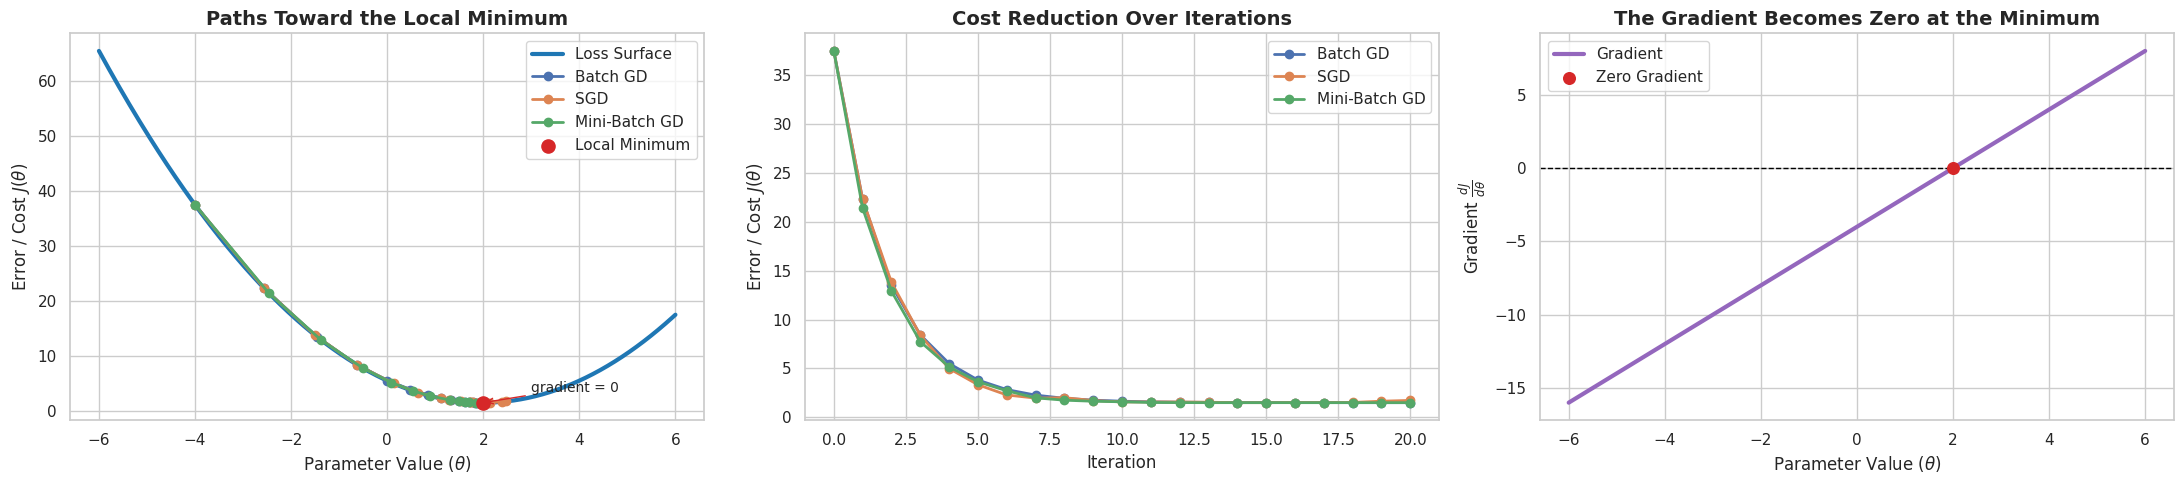

In [19]:
# Compare Batch GD, SGD, and Mini-Batch GD while searching for a local minimum
np.random.seed(7)
rng = np.random.default_rng(7)


def loss_function(theta):
    return (theta - 2.0) ** 2 + 1.5


def exact_gradient(theta):
    return 2 * (theta - 2.0)


def batch_gradient(theta):
    return exact_gradient(theta)


def stochastic_gradient(theta):
    return exact_gradient(theta) + rng.normal(0, 1.2)


def mini_batch_gradient(theta, batch_size=32):
    noise_scale = 0.45 / np.sqrt(batch_size / 32)
    return exact_gradient(theta) + rng.normal(0, noise_scale)


def optimize(theta_start, learning_rate, iterations, gradient_fn):
    theta = theta_start
    theta_history = [theta]
    loss_history = [loss_function(theta)]

    for _ in range(iterations):
        theta = theta - learning_rate * gradient_fn(theta)
        theta_history.append(theta)
        loss_history.append(loss_function(theta))

    return theta_history, loss_history


theta_start = -4.0
learning_rate = 0.12
iterations = 20

batch_theta, batch_loss_history = optimize(theta_start, learning_rate, iterations, batch_gradient)
sgd_theta, sgd_loss_history = optimize(theta_start, learning_rate, iterations, stochastic_gradient)
mini_theta, mini_loss_history = optimize(
    theta_start,
    learning_rate,
    iterations,
    lambda theta: mini_batch_gradient(theta, batch_size=32),
)

theta_grid = np.linspace(-6, 6, 400)
loss_grid = loss_function(theta_grid)
gradient_grid = exact_gradient(theta_grid)
local_minimum_theta = 2.0
local_minimum_loss = loss_function(local_minimum_theta)

fig, axes = plt.subplots(1, 3, figsize=(22, 5))

axes[0].plot(theta_grid, loss_grid, color='#1f77b4', linewidth=3, label='Loss Surface')
axes[0].plot(batch_theta, [loss_function(theta) for theta in batch_theta], marker='o', linewidth=2, label='Batch GD')
axes[0].plot(sgd_theta, [loss_function(theta) for theta in sgd_theta], marker='o', linewidth=2, label='SGD')
axes[0].plot(mini_theta, [loss_function(theta) for theta in mini_theta], marker='o', linewidth=2, label='Mini-Batch GD')
axes[0].scatter(local_minimum_theta, local_minimum_loss, color='#d62728', s=90, zorder=6, label='Local Minimum')
axes[0].annotate(
    'gradient = 0',
    xy=(local_minimum_theta, local_minimum_loss),
    xytext=(local_minimum_theta + 1.0, local_minimum_loss + 2.0),
    arrowprops=dict(arrowstyle='->', color='#d62728'),
    fontsize=10,
)
axes[0].set_title('Paths Toward the Local Minimum', fontsize=14, fontweight='bold')
axes[0].set_xlabel(r'Parameter Value ($\theta$)')
axes[0].set_ylabel(r'Error / Cost $J(\theta)$')
axes[0].legend()

axes[1].plot(batch_loss_history, marker='o', linewidth=2, label='Batch GD')
axes[1].plot(sgd_loss_history, marker='o', linewidth=2, label='SGD')
axes[1].plot(mini_loss_history, marker='o', linewidth=2, label='Mini-Batch GD')
axes[1].set_title('Cost Reduction Over Iterations', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel(r'Error / Cost $J(\theta)$')
axes[1].legend()

axes[2].plot(theta_grid, gradient_grid, color='#9467bd', linewidth=3, label='Gradient')
axes[2].axhline(0, color='black', linestyle='--', linewidth=1)
axes[2].scatter([local_minimum_theta], [0], color='#d62728', s=70, zorder=6, label='Zero Gradient')
axes[2].set_title('The Gradient Becomes Zero at the Minimum', fontsize=14, fontweight='bold')
axes[2].set_xlabel(r'Parameter Value ($\theta$)')
axes[2].set_ylabel(r'Gradient $\frac{dJ}{d\theta}$')
axes[2].legend()

plt.tight_layout()
plt.show()

## Real-World Use Case or Analogy:
Think of Gradient Descent like **A blindfolded hiker trying to find the bottom of a mountain valley**:

*   **The Cost Function**: The physical shape of the mountain. The higher up you are, the higher your error.
*   **The Gradient**: Because you are blindfolded, you use your foot to feel the slope of the ground immediately beneath you. If your toe points down, that is the gradient.
*   **The Update Rule**: You take a physical step in the exact opposite direction of the uphill slope.
*   **The Learning Rate ($\alpha$)**: The length of your physical stride. 
    *   If your stride is 1 millimeter ($\alpha = 0.0001$), you will eventually reach the river at the bottom, but it will take you a decade. 
    *   If your stride is a 100-foot leap ($\alpha = 1.5$), you will jump completely across the valley, land higher on the opposite cliff face, and continue bouncing upward into space.

---